<a href="https://colab.research.google.com/github/cnsbrisecond/M2GRF_test/blob/main/Motion2GRF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
test

In [ ]:
# ============================================================
# improved_gait_lstm_variable_length_5fold_cv_fixed.py
# 修正版: 可変長 LSTM + Δt 分割 + 5Fold クロスバリデーション + NRMSE + グラフ
# - fixes: trial id mapping, per-channel NRMSE, filenames, small robustness tweaks
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.nn.utils.rnn import (
    pad_sequence, pack_padded_sequence, pad_packed_sequence
)

# ============================================================
# 0. reproducibility
# ============================================================
# ============================================================
# ★ データサイズ検証用
# ============================================================
DATA_RATIO = 0.1   # ← 1.0, 0.5, 0.25, 0.1, 0.05 などに変えるだけ
RATIO_SEED = 123   # 再現性用

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# 1. 設定
# ============================================================

file_path = "/content/new_wf_tr_extraction_selected.csv"
encoding = "cp932"
low_memory = False

batch_size = 8
num_epochs = 40
initial_lr = 5e-4

hidden_dim = 96
num_layers = 2
dropout = 0.2
grad_clip = 1.0

# input_keys = [ "股関節EulY","股関節EulX","股関節EulZ","膝関節EulY","膝関節EulX","膝関節EulZ","足関節EulY","足関節EulX","足関節EulZ","体幹Y","体幹X","体幹Z", "左肩峰Xcm","左肩峰Ycm","左肩峰Zcm","左腸骨陵Xcm","左腸骨陵Ycm","左腸骨陵Zcm", "左大転子Xcm","左大転子Ycm","左大転子Zcm","左膝関節外Xcm","左膝関節外Ycm", "左膝関節外Zcm","左膝関節内Xcm","左膝関節内Ycm","左膝関節内Zcm", "左足関節外Xcm","左足関節外Ycm","左足関節外Zcm","左足関節内Xcm", "左足関節内Ycm","左足関節内Zcm","左中足骨外Xcm","左中足骨外Ycm", "左中足骨外Zcm","左中足骨内Xcm","左中足骨内Ycm","左中足骨内Zcm", "右肩峰Xcm","右肩峰Ycm","右肩峰Zcm","右腸骨陵Xcm","右腸骨陵Ycm","右腸骨陵Zcm", "右大転子Xcm","右大転子Ycm","右大転子Zcm","右膝関節外Xcm","右膝関節外Ycm", "右膝関節外Zcm","右膝関節内Xcm","右膝関節内Ycm","右膝関節内Zcm", "右足関節外Xcm","右足関節外Ycm","右足関節外Zcm","右足関節内Xcm", "右足関節内Ycm","右足関節内Zcm","右中足骨外Xcm","右中足骨外Ycm", "右中足骨外Zcm","右中足骨内Xcm","右中足骨内Ycm","右中足骨内Zcm", "左PSISXcm","左PSISYcm","左PSISZcm","右PSISXcm","右PSISYcm","右PSISZcm", "左踵Xcm","左踵Ycm","左踵Zcm","右踵Xcm","右踵Ycm","右踵Zcm", "左股関節点推定Xcm","左股関節点推定Ycm","左股関節点推定Zcm", "左膝関節点推定Xcm","左膝関節点推定Ycm","左膝関節点推定Zcm", "左足関節点推定Xcm","左足関節点推定Ycm","左足関節点推定Zcm", "左中足骨点推定Xcm","左中足骨点推定Ycm","左中足骨点推定Zcm", "右股関節点推定Xcm","右股関節点推定Ycm","右股関節点推定Zcm", "右膝関節点推定Xcm","右膝関節点推定Ycm","右膝関節点推定Zcm", "右足関節点推定Xcm","右足関節点推定Ycm","右足関節点推定Zcm", "右中足骨点推定Xcm","右中足骨点推定Ycm","右中足骨点推定Zcm", "PSIS中点Xcm","PSIS中点Ycm","PSIS中点Zcm", "股関節投影点中点Xcm","股関節投影点中点Ycm","股関節投影点中点Zcm", "肩関節中点Xcm","肩関節中点Ycm","肩関節中点Zcm", "体重心Xcm","体重心Ycm","体重心Zcm" ]

input_keys = [ "左肩峰Xcm","左肩峰Ycm","左肩峰Zcm","左腸骨陵Xcm","左腸骨陵Ycm","左腸骨陵Zcm", "左大転子Xcm","左大転子Ycm","左大転子Zcm","左膝関節外Xcm","左膝関節外Ycm", "左膝関節外Zcm","左膝関節内Xcm","左膝関節内Ycm","左膝関節内Zcm", "左足関節外Xcm","左足関節外Ycm","左足関節外Zcm","左足関節内Xcm", "左足関節内Ycm","左足関節内Zcm","左中足骨外Xcm","左中足骨外Ycm", "左中足骨外Zcm","左中足骨内Xcm","左中足骨内Ycm","左中足骨内Zcm", "右肩峰Xcm","右肩峰Ycm","右肩峰Zcm","右腸骨陵Xcm","右腸骨陵Ycm","右腸骨陵Zcm", "右大転子Xcm","右大転子Ycm","右大転子Zcm","右膝関節外Xcm","右膝関節外Ycm", "右膝関節外Zcm","右膝関節内Xcm","右膝関節内Ycm","右膝関節内Zcm", "右足関節外Xcm","右足関節外Ycm","右足関節外Zcm","右足関節内Xcm", "右足関節内Ycm","右足関節内Zcm","右中足骨外Xcm","右中足骨外Ycm", "右中足骨外Zcm","右中足骨内Xcm","右中足骨内Ycm","右中足骨内Zcm", "左PSISXcm","左PSISYcm","左PSISZcm","右PSISXcm","右PSISYcm","右PSISZcm", "左踵Xcm","左踵Ycm","左踵Zcm","右踵Xcm","右踵Ycm","右踵Zcm", "左股関節点推定Xcm","左股関節点推定Ycm","左股関節点推定Zcm", "左膝関節点推定Xcm","左膝関節点推定Ycm","左膝関節点推定Zcm", "左足関節点推定Xcm","左足関節点推定Ycm","左足関節点推定Zcm", "左中足骨点推定Xcm","左中足骨点推定Ycm","左中足骨点推定Zcm", "右股関節点推定Xcm","右股関節点推定Ycm","右股関節点推定Zcm", "右膝関節点推定Xcm","右膝関節点推定Ycm","右膝関節点推定Zcm", "右足関節点推定Xcm","右足関節点推定Ycm","右足関節点推定Zcm", "右中足骨点推定Xcm","右中足骨点推定Ycm","右中足骨点推定Zcm", "PSIS中点Xcm","PSIS中点Ycm","PSIS中点Zcm", "股関節投影点中点Xcm","股関節投影点中点Ycm","股関節投影点中点Zcm", "肩関節中点Xcm","肩関節中点Ycm","肩関節中点Zcm", "体重心Xcm","体重心Ycm","体重心Zcm" ]
output_keys = [ "左足Fzkg","左足Fxkg","左足Fykg", "右足Fzkg","右足Fxkg","右足Fykg" ]
param_keys = ["年齢", "身長", "体重", "ID", "p_side"]

# 保存ディレクトリ作成
save_dir = f"/content/drive/MyDrive/t-teramae/MLP_results_nrmse_ratio_{DATA_RATIO}"
os.makedirs(save_dir, exist_ok=True)
# fig_dir = f"/content/drive/MyDrive/t-teramae/MLP_fig_nrmse_ratio_{DATA_RATIO}"
# os.makedirs(fig_dir, exist_ok=True)

# ============================================================
# 2. CSV 読み込み
# ============================================================
df = pd.read_csv(file_path, encoding=encoding, low_memory=low_memory)
print("CSV 読み込み完了:", len(df))

# 時間列を自動検出
possible_time_cols = ["time", "Time", "timestamp", "時間", "TIME"]
TIME_COL = next((c for c in possible_time_cols if c in df.columns), None)
if TIME_COL is None:
    raise KeyError("時間列が見つかりません")

df[TIME_COL] = df[TIME_COL].astype(float)

# ============================================================
# 3. Δt によるトライアル分割
# ============================================================
tol = 1e-3   # 必要ならここを少し大きくする（例: 1e-3）ことを検討
dt = df[TIME_COL].diff().fillna(0.0).values
is_regular = np.isclose(dt, 0.001, atol=tol)

trial_id = []
cur = 0
for i, reg in enumerate(is_regular):
    if i == 0:
        trial_id.append(cur)
        continue
    if not reg:
        cur += 1
    trial_id.append(cur)

df["trial_id"] = np.array(trial_id)
num_trials = int(df["trial_id"].max() + 1)
print("検出されたトライアル:", num_trials)

# ============================================================
# 4. トライアルごとにシーケンス抽出
#    → ここで元の trial id を保持する（raw_trial_ids）
# ============================================================
raw_X, raw_y, raw_trial_ids = [], [], []
MIN_LEN = 5

for tid in range(num_trials):
    chunk = df[df["trial_id"] == tid]
    if len(chunk) < MIN_LEN:
        continue
    if chunk[input_keys].isna().any().any() or chunk[output_keys].isna().any().any():
        continue

    raw_X.append(chunk[input_keys].values.astype(np.float32))
    # -------------------------------
    # ★ 体重正規化を追加
    # -------------------------------
    body_weight = float(chunk["体重"].iloc[0])  # trial内は一定のはず

    if body_weight == 0:
        body_weight = 1.0  # 念のため

    y_norm = chunk[output_keys].values.astype(np.float32) / body_weight

    raw_y.append(y_norm)
    raw_trial_ids.append(int(tid))

print("有効トライアル:", len(raw_X))

if len(raw_X) == 0:
    raise RuntimeError("有効なトライアルが0件です。入力データ / フィルタ条件を確認してください。")


# raw_y から global range を算出（これが正解）
all_y = np.concatenate(raw_y, axis=0)
global_range = all_y.max(axis=0) - all_y.min(axis=0)
global_range[global_range == 0] = 1.0

range_path = os.path.join(save_dir, "global_output_range.npy")
np.save(range_path, global_range)

# ============================================================
# Dataset / DataLoader
# ============================================================
class VarSeqDataset(Dataset):
    def __init__(self, X_list, y_list, raw_indices):
        self.X = X_list
        self.y = y_list
        self.raw_indices = raw_indices

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx])
        y = torch.tensor(self.y[idx])
        raw_index = self.raw_indices[idx]
        return x, y, x.size(0), raw_index

def collate_fn(batch):
    xs, ys, lengths, raw_indices = zip(*batch)
    xs_pad = pad_sequence(xs, batch_first=True)
    ys_pad = pad_sequence(ys, batch_first=True)
    lengths = torch.tensor(lengths)
    raw_indices = torch.tensor(raw_indices)
    return xs_pad, ys_pad, lengths, raw_indices

# ============================================================
# 6. モデル
# ============================================================
class MLPModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )

    def forward(self, x_pad, lengths):
        return self.net(x_pad)


class LSTMVarModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.ln = nn.LayerNorm(hidden_dim)
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x_pad, lengths):
        packed = pack_padded_sequence(x_pad, lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True)

        # out: (B, Lmax, H)
        B, Lmax, H = out.shape
        ar = torch.arange(Lmax, device=out.device)[None, :]
        mask = (ar < lengths[:, None])  # (B, Lmax)
        flat = out.reshape(-1, H)
        valid_idx = mask.reshape(-1).nonzero(as_tuple=False).squeeze(1)

        flat_norm = flat.clone()
        if valid_idx.numel() > 0:
            ln_out = self.ln(flat[valid_idx]).to(flat_norm.dtype)
            flat_norm[valid_idx] = ln_out

        out = flat_norm.reshape(B, Lmax, H)
        out = self.relu(self.fc1(out))
        out = self.drop(out)
        out = self.fc2(out)  # (B, Lmax, output_dim)
        return out

# ============================================================
# SCINet blocks
# ============================================================
class SCIBlock(nn.Module):
    def __init__(self, channels, hidden=64):
        super().__init__()
        self.f = nn.Sequential(
            nn.Conv1d(channels, hidden, 3, padding=1),
            nn.ReLU(),
            nn.Conv1d(hidden, channels, 3, padding=1)
        )
        self.g = nn.Sequential(
            nn.Conv1d(channels, hidden, 3, padding=1),
            nn.ReLU(),
            nn.Conv1d(hidden, channels, 3, padding=1)
        )

    def forward(self, x):
        # x: (B, C, T)
        B, C, T = x.shape

        even = x[:, :, ::2]
        odd  = x[:, :, 1::2]

        fe = self.f(odd)
        go = self.g(even)

        even = even + fe
        odd  = odd  + go

        # ---- ★ 入力長Tを完全保存してinterleave ----
        out = torch.zeros(B, C, T, device=x.device)

        out[:, :, ::2] = even
        out[:, :, 1::2] = odd[:, :, :out[:, :, 1::2].shape[2]]

        return out


class SCINet(nn.Module):
    def __init__(self, channels, levels=3):
        super().__init__()
        self.levels = nn.ModuleList([SCIBlock(channels) for _ in range(levels)])

    def forward(self, x):
        for blk in self.levels:
            x = blk(x)
        return x


# ============================================================
# 可変長対応 SCINet モデル
# ============================================================

class SCINetVarModel(nn.Module):
    def __init__(self, input_dim, output_dim, sci_levels=3, hidden=64):
        super().__init__()
        self.input_proj = nn.Conv1d(input_dim, hidden, 1)
        self.scinet = SCINet(hidden, levels=sci_levels)
        self.output_proj = nn.Conv1d(hidden, output_dim, 1)

    def forward(self, x_pad, lengths):
        orig_L = lengths.max().item()
        # x_pad: (B, L, C)
        B, L, C = x_pad.shape

        # ---- ★ 奇数長を偶数長にpadding（超重要） ----
        if L % 2 != 0:
            pad = torch.zeros(B, 1, C, device=x_pad.device, dtype=x_pad.dtype)
            x_pad = torch.cat([x_pad, pad], dim=1)

        x = x_pad.transpose(1, 2)  # (B, C, L)
        x = self.input_proj(x)
        x = self.scinet(x)
        x = self.output_proj(x)
        x = x.transpose(1, 2)

        # ---- 元の長さに戻す ----
        x = x[:, :orig_L]

        return x

# ============================================================
# TCN blocks
# ============================================================

class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()


class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, stride, dilation, padding, dropout=0.2):
        super().__init__()

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        self.net = nn.Sequential(
            self.conv1, self.chomp1, self.relu1, self.drop1,
            self.conv2, self.chomp2, self.relu2, self.drop2
        )

        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TCN(nn.Module):
    def __init__(self, input_ch, num_channels, kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        for i in range(len(num_channels)):
            dilation = 2 ** i
            in_ch = input_ch if i == 0 else num_channels[i-1]
            out_ch = num_channels[i]
            layers.append(
                TemporalBlock(
                    in_ch, out_ch,
                    kernel_size=kernel_size,
                    stride=1,
                    dilation=dilation,
                    padding=(kernel_size-1) * dilation,
                    dropout=dropout
                )
            )
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# ============================================================
# 可変長対応 TCN モデル
# ============================================================

class TCNVarModel(nn.Module):
    def __init__(self, input_dim, output_dim,
                 channels=[64, 64, 96, 96], kernel_size=3, dropout=0.2):
        super().__init__()

        self.tcn = TCN(input_dim, channels,
                       kernel_size=kernel_size,
                       dropout=dropout)

        self.fc = nn.Conv1d(channels[-1], output_dim, 1)

    def forward(self, x_pad, lengths):
        # x_pad: (B, L, C)
        x = x_pad.transpose(1, 2)   # (B, C, L)
        y = self.tcn(x)
        y = self.fc(y)
        y = y.transpose(1, 2)      # (B, L, output_dim)
        return y


input_dim = raw_X[0].shape[1]
output_dim = raw_y[0].shape[1]

def compute_rrmse(y_true, y_pred, eps=1e-8):
    """
    rRMSE = RMSE / RMS(y_true)
    """
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    rms_true = np.sqrt(np.mean(y_true ** 2))
    return rmse / (rms_true + eps)

# ============================================================
# 7. GroupKFold クロスバリデーション（被験者 ID ごとにグループ分割）
# ============================================================
from sklearn.model_selection import GroupKFold

fold_results = []
per_fold_channel_nrmse = []

# We'll need mapping from "index in raw_X" -> original trial id -> subject ID
trial_to_subject = df.groupby("trial_id")["ID"].first().to_dict()

# raw_X の各要素（トライアル）の subject ID をグループラベルにする
groups = np.array([trial_to_subject[raw_trial_ids[i]] for i in range(len(raw_X))])

# gkf = GroupKFold(n_splits=5)
from sklearn.model_selection import GroupShuffleSplit

gkf = GroupShuffleSplit(n_splits=50, test_size=0.2, random_state=42)

for fold, (train_idx, val_idx) in enumerate(gkf.split(raw_X, groups=groups)):
    fold_id = fold + 1
    existing_csv = f"{save_dir}/fold_{fold_id}_nrmse_data.csv"
    # ============================================================
    # ★ 既存結果がある fold は完全スキップして NRMSE を復元
    # ============================================================
    if os.path.exists(existing_csv):
        print(f"\n>>> Fold {fold_id} は既に完了済み。結果を読み込んでスキップ")

        prev = pd.read_csv(existing_csv)

        pred_cols = [c for c in prev.columns if c.startswith("pred_")]
        tgt_cols  = [c for c in prev.columns if c.startswith("tgt_")]

        pred_arr = prev[pred_cols].values
        tgt_arr  = prev[tgt_cols].values

        ch_rmse = np.sqrt(((pred_arr - tgt_arr)**2).mean(axis=0))
        range_path = os.path.join(save_dir, f"fold_{fold_id}_range.npy")
        ch_range = np.load(range_path)

        ch_nrmse = ch_rmse / ch_range

        fold_results.append(float(ch_nrmse.mean()))
        per_fold_channel_nrmse.append(ch_nrmse)

        continue
    # ============================================================
    # ★ 学習データを DATA_RATIO だけ間引く（超重要）
    # ============================================================
    rng = np.random.default_rng(RATIO_SEED + fold)

    if DATA_RATIO < 1.0:
        n_train = len(train_idx)
        keep_n = max(1, int(n_train * DATA_RATIO))
        chosen = rng.choice(train_idx, size=keep_n, replace=False)
        train_idx = np.sort(chosen)

        print(f"  >> DATA_RATIO = {DATA_RATIO}  :  {keep_n} / {n_train} trials used for training")

    print()
    print("="*60)
    print(f" Split {fold+1} / 50  (GroupShuffleSplit by subject)")
    print("="*60)

    # ---- データ分割 ----
    X_train = [raw_X[i] for i in train_idx]
    y_train = [raw_y[i] for i in train_idx]
    X_val   = [raw_X[i] for i in val_idx]
    y_val   = [raw_y[i] for i in val_idx]

    # ---- 標準化 ----
    concat_Xtrain = np.concatenate(X_train, axis=0)
    mean = concat_Xtrain.mean(axis=0)
    std = concat_Xtrain.std(axis=0)
    std[std == 0] = 1.0

    X_train = [(x - mean)/std for x in X_train]
    X_val = [(x - mean)/std for x in X_val]

    train_loader = DataLoader(
        VarSeqDataset(X_train, y_train, train_idx),
        batch_size=batch_size, shuffle=True,
        collate_fn=collate_fn
    )

    val_loader = DataLoader(
        VarSeqDataset(X_val, y_val, val_idx),
        batch_size=batch_size, shuffle=False,
        collate_fn=collate_fn
    )

    # ---- モデル ----
    model = MLPModel(input_dim, output_dim).to(device)
    # model = SCINetVarModel(input_dim, output_dim,
    #                    sci_levels=3, hidden=64).to(device)

    # model = TCNVarModel(input_dim, output_dim,
    #                     channels=[64, 64, 96, 96],
    #                     kernel_size=3,
    #                     dropout=dropout).to(device)

    # model = LSTMVarModel(input_dim, hidden_dim, output_dim,
    #                      num_layers=num_layers, dropout=dropout).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=initial_lr)
    scaler = GradScaler()

    # ---- train データだけで range を計算（これが統計的に正しい）----
    train_y_all = np.concatenate([raw_y[i] for i in train_idx], axis=0)
    channel_range = train_y_all.max(axis=0) - train_y_all.min(axis=0)
    channel_range[channel_range == 0] = 1.0
    range_path = os.path.join(save_dir, f"fold_{fold_id}_range.npy")
    np.save(range_path, channel_range)

    # ============================================================
    # 学習
    # ============================================================
    for ep in range(1, num_epochs+1):
        model.train()
        for Xb, yb, Lb, _ in train_loader:
            Xb, yb, Lb = Xb.to(device), yb.to(device), Lb.to(device)
            opt.zero_grad()

            with autocast():
                pred = model(Xb, Lb)

                B, Lmax, C = pred.shape
                ar = torch.arange(Lmax, device=device)[None, :]
                mask = (ar < Lb[:, None]).unsqueeze(-1)

                se = ((pred - yb)**2) * mask
                denom = mask.sum() * C
                loss = se.sum() / denom


            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(opt)
            scaler.update()

        if ep % 10 == 0:
            print(f"  Epoch {ep} done.")
    # ============================================================
    # 検証
    # ============================================================
    model.eval()
    preds = []
    tgts = []
    val_raw_indices = []

    with torch.no_grad():
        for Xv, yv, Lv, raw_idx in val_loader:
            Xv, yv, Lv = Xv.to(device), yv.to(device), Lv.to(device)
            pred = model(Xv, Lv)

            pred = pred.cpu().numpy()
            yv = yv.cpu().numpy()
            Lv = Lv.cpu().numpy()
            raw_idx = raw_idx.numpy()

            for i in range(pred.shape[0]):
                L = int(Lv[i])
                preds.append(pred[i, :L])
                tgts.append(yv[i, :L])
                val_raw_indices.append(int(raw_idx[i]))

    # Concatenate for metric computation
    pred_concat = np.concatenate(preds, axis=0)  # (N_total, C)
    tgt_concat = np.concatenate(tgts, axis=0)    # (N_total, C)

    # per-channel NRMSE: RMSE(channel) / range(channel)
    channel_rmse = np.sqrt(((pred_concat - tgt_concat)**2).mean(axis=0))  # shape (C,)
    # channel_range = tgt_concat.max(axis=0) - tgt_concat.min(axis=0)
    # channel_range[channel_range == 0] = 1.0
    range_path = os.path.join(save_dir, f"fold_{fold_id}_range.npy")
    channel_range = np.load(range_path)

    channel_nrmse = channel_rmse / channel_range  # shape (C,)

    fold_nrmse = float(channel_nrmse.mean())
    fold_results.append(fold_nrmse)
    per_fold_channel_nrmse.append(channel_nrmse)

    print(f"  Fold {fold+1} channel RMSE = {channel_rmse}")
    print(f"  Fold {fold+1} channel NRMSE = {channel_nrmse}")
    print(f"  Fold {fold+1} NRMSE (mean over channels) = {fold_nrmse:.6f}")

    # ============================================================
    # NRMSE 計算に使用した元データを保存（ID 情報付き）
    # ============================================================

    # raw_trial_ids maps index in raw_X -> original trial_id
    # val_idx contains indices into raw_X; so val_raw_trial_indices is list of original raw indices used in order
    rows = []
    # val_raw_trial_indices length equals number of validation samples
    for sample_i, (p_arr, t_arr) in enumerate(zip(preds, tgts)):
        L = len(p_arr)
        raw_index = val_raw_indices[sample_i]
        orig_trial_id = raw_trial_ids[raw_index]  # original trial id in df
        subject_id = trial_to_subject.get(orig_trial_id, -1)

        for t_idx in range(L):
            row = {"raw_index": raw_index, "trial_id": orig_trial_id, "ID": subject_id, "time_idx": t_idx}
            for ch in range(output_dim):
                row[f"pred_{output_keys[ch]}"] = float(p_arr[t_idx, ch])
                row[f"tgt_{output_keys[ch]}"] = float(t_arr[t_idx, ch])
            rows.append(row)

    df_nrmse = pd.DataFrame(rows)
    df_nrmse.to_csv(f"{save_dir}/fold_{fold+1}_nrmse_data.csv", index=False)

    # ============================================================
    # 各検証トライアルの CSV 保存（ファイル名に raw trial id と subject ID を含める）
    # ============================================================
    # preds/tgts order corresponds to order of val_idx
    for i, (p, t) in enumerate(zip(preds, tgts)):
        raw_index = val_raw_indices[i]
        orig_trial_id = raw_trial_ids[raw_index]
        subject_id = trial_to_subject.get(orig_trial_id, -1)

        df_out = pd.DataFrame()
        df_out["time_index"] = np.arange(len(p))
        for ch in range(output_dim):
            df_out[f"pred_{output_keys[ch]}"] = p[:, ch]
            df_out[f"tgt_{output_keys[ch]}"] = t[:, ch]

        fname = f"{save_dir}/fold_{fold+1}_rawidx_{raw_index}_trialid_{orig_trial_id}_ID_{subject_id}.csv"
        df_out.to_csv(fname, index=False)

    # ============================================================
    # グラフ保存（ファイル名に raw trial id を含める）
    # ============================================================
    # for i, (p, t) in enumerate(zip(preds, tgts)):
    #     raw_index = int(val_idx[i])
    #     orig_trial_id = raw_trial_ids[raw_index]
    #     subject_id = trial_to_subject.get(orig_trial_id, -1)

    #     plt.figure(figsize=(12,5))
    #     for ch in range(p.shape[1]):
    #         plt.plot(t[:, ch], "--", label=f"tgt {output_keys[ch]}")
    #         plt.plot(p[:, ch], label=f"pred {output_keys[ch]}")
    #     plt.title(f"Fold {fold+1} : Validation Trial {i} (rawidx {raw_index}, trial {orig_trial_id}, ID {subject_id})")
    #     plt.legend()
    #     plt.tight_layout()
    #     plt.savefig(f"{fig_dir}/fold_{fold+1}_rawidx_{raw_index}_trialid_{orig_trial_id}_ID_{subject_id}.png")
    #     plt.close()
    # ---- fold 完了フラグ ----
    # with open(flag_file, "w") as f:
    #     f.write("done")
    # print(f">>> Fold {fold_id} 完了。フラグ保存")

# ============================================================
# クロスバリデーション結果の保存
# ============================================================
cv_df = pd.DataFrame({
    "fold": list(range(1, len(fold_results)+1)),
    "NRMSE_mean_over_channels": fold_results
})
cv_df.loc[len(cv_df)] = ["mean", np.mean(fold_results)]
cv_df.to_csv(f"{save_dir}/cv_results.csv", index=False)

# cv_df.to_csv(f"{save_dir}/cv_results.csv", index=False)

# Optionally save per-fold per-channel NRMSE table
channel_cols = [f"NRMSE_{k}" for k in output_keys]
channel_table = pd.DataFrame(np.vstack(per_fold_channel_nrmse), columns=channel_cols)
channel_table.insert(0, "fold", list(range(1, len(per_fold_channel_nrmse)+1)))
channel_table.loc[len(channel_table)] = ["mean"] + list(channel_table[channel_cols].mean(axis=0))
channel_table.to_csv(f"{save_dir}/cv_channel.csv", index=False)

# channel_table.to_csv(f"{save_dir}/cv_channel_nrmse.csv", index=False)

print("="*60)
print(" 50 Subject-wise Holdout Validation Results")
print("="*60)
for i, v in enumerate(fold_results):
    print(f" Fold {i+1} NRMSE = {v:.6f}")
print(" 平均 NRMSE =", np.mean(fold_results))
print(f"\n→ 保存先: {save_dir}/cv_results.csv")


Using device: cuda
CSV 読み込み完了: 884918
検出されたトライアル: 6572
有効トライアル: 514
  >> DATA_RATIO = 0.1  :  41 / 413 trials used for training

 Split 1 / 50  (GroupShuffleSplit by subject)


/tmp/ipython-input-1663/665016509.py:516: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-1663/665016509.py:534: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch 10 done.
  Epoch 20 done.
  Epoch 30 done.
  Epoch 40 done.
  Fold 1 channel RMSE = [0.17408007 0.04492434 0.03460138 0.17603679 0.03804591 0.03853623]
  Fold 1 channel NRMSE = [0.1287854  0.10920504 0.15265758 0.14871125 0.10414439 0.14346775]
  Fold 1 NRMSE (mean over channels) = 0.131162
  >> DATA_RATIO = 0.1  :  39 / 390 trials used for training

 Split 2 / 50  (GroupShuffleSplit by subject)


/tmp/ipython-input-1663/665016509.py:516: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-1663/665016509.py:534: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch 10 done.
  Epoch 20 done.
  Epoch 30 done.
  Epoch 40 done.
  Fold 2 channel RMSE = [0.23835616 0.04083353 0.03308805 0.18252382 0.03650395 0.02945152]
  Fold 2 channel NRMSE = [0.18270412 0.10026914 0.16050774 0.14889733 0.07926998 0.1258352 ]
  Fold 2 NRMSE (mean over channels) = 0.132914
  >> DATA_RATIO = 0.1  :  39 / 395 trials used for training

 Split 3 / 50  (GroupShuffleSplit by subject)


...

  Epoch 10 done.
  Epoch 20 done.
  Epoch 30 done.
  Epoch 40 done.
  Fold 48 channel RMSE = [0.19100925 0.0337627  0.03764801 0.17467251 0.03968474 0.03285808]
  Fold 48 channel NRMSE = [0.16595054 0.0935945  0.19314317 0.13420664 0.07664192 0.12716842]
  Fold 48 NRMSE (mean over channels) = 0.131784
  >> DATA_RATIO = 0.1  :  38 / 384 trials used for training

 Split 49 / 50  (GroupShuffleSplit by subject)


/tmp/ipython-input-1663/665016509.py:516: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-1663/665016509.py:534: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch 10 done.
  Epoch 20 done.
  Epoch 30 done.
  Epoch 40 done.
  Fold 49 channel RMSE = [0.18677059 0.03988627 0.03382818 0.13353871 0.03319608 0.02788773]
  Fold 49 channel NRMSE = [0.1568876  0.10281245 0.12284018 0.10475229 0.07197708 0.12567267]
  Fold 49 NRMSE (mean over channels) = 0.114157
  >> DATA_RATIO = 0.1  :  42 / 423 trials used for training

 Split 50 / 50  (GroupShuffleSplit by subject)


/tmp/ipython-input-1663/665016509.py:516: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-1663/665016509.py:534: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch 10 done.
  Epoch 20 done.
  Epoch 30 done.
  Epoch 40 done.
  Fold 50 channel RMSE = [0.21341595 0.03224132 0.02974587 0.1920739  0.03222543 0.03157362]
  Fold 50 channel NRMSE = [0.16756625 0.0800681  0.12912111 0.15321429 0.09347229 0.14754228]
  Fold 50 NRMSE (mean over channels) = 0.128497
 50 Subject-wise Holdout Validation Results
 Fold 1 NRMSE = 0.131162
 Fold 2 NRMSE = 0.132914
 Fold 3 NRMSE = 0.105136
 Fold 4 NRMSE = 0.138604
 Fold 5 NRMSE = 0.133991
 Fold 6 NRMSE = 0.132079
 Fold 7 NRMSE = 0.152909
 Fold 8 NRMSE = 0.138669
 Fold 9 NRMSE = 0.123760
 Fold 10 NRMSE = 0.146576
 Fold 11 NRMSE = 0.119118
 Fold 12 NRMSE = 0.122695
 Fold 13 NRMSE = 0.129989
 Fold 14 NRMSE = 0.124038
 Fold 15 NRMSE = 0.119487
 Fold 16 NRMSE = 0.128005
 Fold 17 NRMSE = 0.136173
 Fold 18 NRMSE = 0.110322
 Fold 19 NRMSE = 0.130150
 Fold 20 NRMSE = 0.141550
 Fold 21 NRMSE = 0.128054
 Fold 22 NRMSE = 0.130802
 Fold 23 NRMSE = 0.104296
 Fold 24 NRMSE = 0.105110
 Fold 25 NRMSE = 0.127962
 Fold 26 NRM

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/tmp/ipython-input-1026/337

                          Mixed Linear Model Regression Results
Model:                         MixedLM             Dependent Variable:             RMSE  
No. Observations:              1848                Method:                         REML  
No. Groups:                    77                  Scale:                          0.0002
Min. group size:               24                  Log-Likelihood:                 inf   
Max. group size:               24                  Converged:                      Yes   
Mean group size:               24.0                                                      
-----------------------------------------------------------------------------------------
                                      Coef.   Std.Err.    z    P>|z|   [0.025     0.975] 
-----------------------------------------------------------------------------------------
Intercept                             -0.000 31528.111  -0.000 1.000 -61793.961 61793.961
Model[T.LSTM]                       

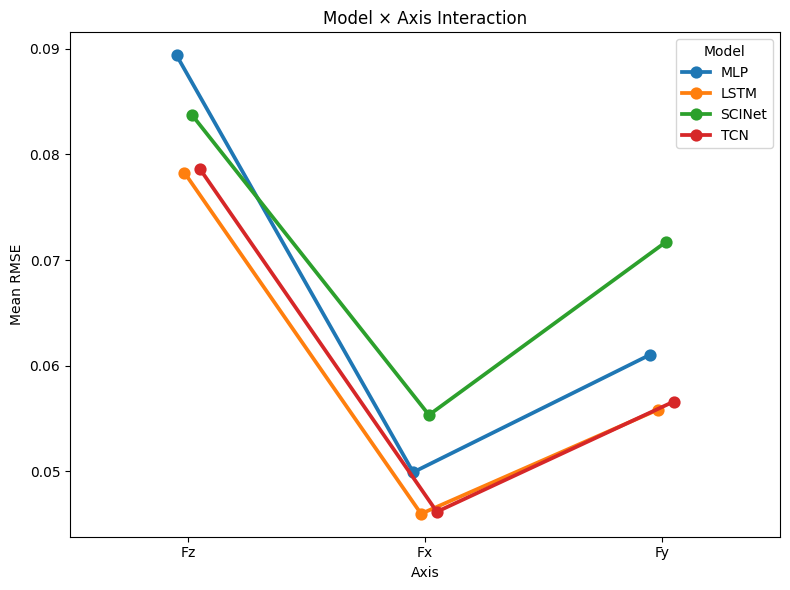

   Axis  Model1  Model2          t         p_raw        p_holm
17   Fy  SCINet     TCN  24.067210  6.956295e-54  1.252133e-52
11   Fx  SCINet     TCN  19.601688  1.420474e-43  2.414806e-42
13   Fy     MLP  SCINet -18.100562  7.263366e-40  1.162139e-38
15   Fy    LSTM  SCINet -18.074718  8.433736e-40  1.265060e-38
9    Fx    LSTM  SCINet -14.397239  2.970011e-30  4.158015e-29
7    Fx     MLP  SCINet -13.400230  1.398233e-27  1.817703e-26
2    Fz     MLP     TCN  11.996741  8.609689e-24  1.033163e-22
14   Fy     MLP     TCN   9.682211  1.369120e-17  1.506032e-16
8    Fx     MLP     TCN   9.465788  5.071150e-17  5.071150e-16
0    Fz     MLP    LSTM   8.086437  1.745563e-13  1.571007e-12
5    Fz  SCINet     TCN   7.818021  8.086365e-13  6.469092e-12
1    Fz     MLP  SCINet   6.293457  3.115180e-09  1.782456e-08
12   Fy     MLP    LSTM   6.310325  2.857322e-09  1.782456e-08
6    Fx     MLP    LSTM   6.332781  2.546366e-09  1.782456e-08
3    Fz    LSTM  SCINet  -5.740862  4.911326e-08  1.964

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# ===============================
# ① モデルフォルダ
# ===============================

base_dir = r"/content/drive/MyDrive/t-teramae/"

model_folders = {
    "MLP": os.path.join(base_dir, "MLP_results_nrmse_ratio_1.0"),
    "LSTM": os.path.join(base_dir, "LSTM_results_nrmse_ratio_1.0"),
    "SCINet": os.path.join(base_dir, "SCINet_results_nrmse_ratio_1.0"),
    "TCN": os.path.join(base_dir, "TCN_results_nrmse_ratio_1.0"),
}

all_data = []

# ===============================
# ② fold × ID × Axis RMSE計算
# ===============================

for model_name, folder in model_folders.items():

    files = sorted(
        glob.glob(os.path.join(folder, "fold_*_nrmse_data.csv")),
        key=lambda x: int(os.path.basename(x).split("_")[1])
    )

    for file in files:

        fold_id = int(os.path.basename(file).split("_")[1])

        df = pd.read_csv(file)

        # # 🔥 保存済みレンジ読み込み
        range_path = os.path.join(folder, f"fold_{fold_id}_range.npy")
        channel_range = np.load(range_path)

        for subject in df["ID"].unique():

            sub_df = df[df["ID"] == subject]

            for axis in ["Fz", "Fx", "Fy"]:

                for side in ["左足", "右足"]:

                    pred = sub_df[f"pred_{side}{axis}kg"].values
                    true = sub_df[f"tgt_{side}{axis}kg"].values

                    rmse = np.sqrt(np.mean((true - pred) ** 2))

                    # レンジも左右別にする
                    if side == "左足":
                        if axis == "Fz":
                            denom = channel_range[0]
                        elif axis == "Fx":
                            denom = channel_range[1]
                        else:
                            denom = channel_range[2]
                    else:
                        if axis == "Fz":
                            denom = channel_range[3]
                        elif axis == "Fx":
                            denom = channel_range[4]
                        else:
                            denom = channel_range[5]

                    if denom == 0:
                        nrmse = np.nan
                    else:
                        nrmse = rmse / denom

                    all_data.append([subject, model_name, axis, side, nrmse])


# ===============================
# ③ fold平均 → 被験者平均
# ===============================

long_df = pd.DataFrame(
    all_data, columns=["ID", "Model", "Axis", "Side", "RMSE"]
)

subject_mean_df = (
    long_df
    .groupby(["ID", "Model", "Axis", "Side"])["RMSE"]
    .mean()
    .reset_index()
)

subject_mean_df["Model"] = pd.Categorical(
    subject_mean_df["Model"],
    categories=["MLP", "LSTM", "SCINet", "TCN"]
)

subject_mean_df["Axis"] = pd.Categorical(
    subject_mean_df["Axis"],
    categories=["Fz", "Fx", "Fy"]
)

subject_mean_df["Side"] = pd.Categorical(
    subject_mean_df["Side"],
    categories=["左足", "右足"]
)

model = smf.mixedlm(
    "RMSE ~ Model * Axis * Side",
    subject_mean_df,
    groups=subject_mean_df["ID"]
)

result = model.fit(reml=True, method="lbfgs")
print(result.summary())

import matplotlib.pyplot as plt
import seaborn as sns

# 平均とSE計算
summary_df = (
    subject_mean_df
    .groupby(["Model", "Axis"])["RMSE"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

summary_df["se"] = summary_df["std"] / (summary_df["count"] ** 0.5)

plt.figure(figsize=(8,6))

sns.pointplot(
    data=summary_df,
    x="Axis",
    y="mean",
    hue="Model",
    dodge=True,
    markers="o",
    capsize=0.1,
    errwidth=1
)

plt.ylabel("Mean RMSE")
plt.title("Model × Axis Interaction")
plt.tight_layout()
plt.show()

from itertools import combinations
from scipy.stats import ttest_rel
import statsmodels.stats.multitest as smm

results = []

for axis in ["Fz", "Fx", "Fy"]:

    df_axis = subject_mean_df[subject_mean_df["Axis"] == axis]

    for m1, m2 in combinations(["MLP","LSTM","SCINet","TCN"], 2):

        d1 = df_axis[df_axis["Model"] == m1]["RMSE"].values
        d2 = df_axis[df_axis["Model"] == m2]["RMSE"].values

        t, p = ttest_rel(d1, d2)

        results.append([axis, m1, m2, t, p])

posthoc_df = pd.DataFrame(
    results, columns=["Axis","Model1","Model2","t","p_raw"]
)

# Holm補正
posthoc_df["p_holm"] = smm.multipletests(
    posthoc_df["p_raw"], method="holm"
)[1]

print(posthoc_df.sort_values("p_holm"))

import numpy as np

def cohens_d_paired(x, y):
    diff = x - y
    return diff.mean() / diff.std(ddof=1)

effect_sizes = []

for axis in ["Fz","Fx","Fy"]:

    df_axis = subject_mean_df[subject_mean_df["Axis"] == axis]

    for m1, m2 in combinations(["MLP","LSTM","SCINet","TCN"], 2):

        d1 = df_axis[df_axis["Model"] == m1]["RMSE"].values
        d2 = df_axis[df_axis["Model"] == m2]["RMSE"].values

        d = cohens_d_paired(d1, d2)

        effect_sizes.append([axis, m1, m2, d])

effect_df = pd.DataFrame(
    effect_sizes, columns=["Axis","Model1","Model2","Cohens_d"]
)

print(effect_df.sort_values("Cohens_d"))


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


                        Mixed Linear Model Regression Results
Model:                        MixedLM            Dependent Variable:            RMSE  
No. Observations:             4620               Method:                        REML  
No. Groups:                   77                 Scale:                         0.0003
Min. group size:              60                 Log-Likelihood:                inf   
Max. group size:              60                 Converged:                     Yes   
Mean group size:              60.0                                                    
--------------------------------------------------------------------------------------
                                   Coef.   Std.Err.    z    P>|z|   [0.025     0.975] 
--------------------------------------------------------------------------------------
Intercept                           0.000 24649.884   0.000 1.000 -48312.885 48312.885
Ratio[T.0.9]                        0.001     0.003   0.330 0.741   

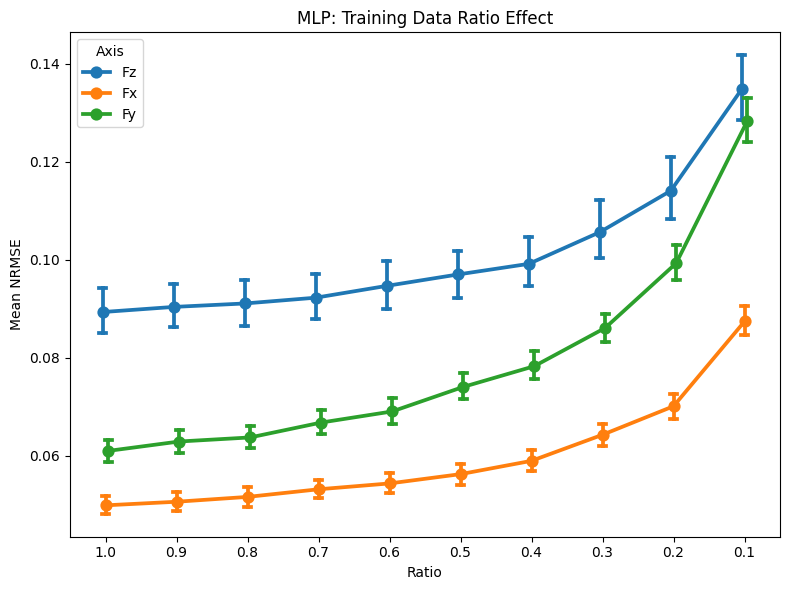

    Axis Ratio1 Ratio2          t         p_raw        p_holm
98    Fy    1.0    0.1 -44.071677  7.559393e-89  1.020518e-86
106   Fy    0.9    0.1 -42.750684  5.619500e-87  7.530130e-85
119   Fy    0.7    0.1 -42.540291  1.127825e-86  1.500007e-84
113   Fy    0.8    0.1 -42.381760  1.910049e-86  2.521265e-84
124   Fy    0.6    0.1 -42.018703  6.423449e-86  8.414718e-84
..   ...    ...    ...        ...           ...           ...
45    Fx    1.0    0.9  -3.224708  1.541820e-03  7.709099e-03
0     Fz    1.0    0.9  -3.153792  1.940287e-03  7.761149e-03
99    Fy    0.9    0.8  -2.930903  3.898361e-03  1.169508e-02
17    Fz    0.8    0.7  -2.770027  6.299688e-03  1.259938e-02
9     Fz    0.9    0.8  -1.907578  5.831930e-02  5.831930e-02

[135 rows x 6 columns]


In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# ===============================
# ① MLP ratio フォルダ
# ===============================

base_dir = r"/content/drive/MyDrive/t-teramae/"

ratios = [1.0,0.9,0.8,0.7,0.6,0.5,0.4,0.3,0.2,0.1]

mlp_folders = {
    f"{r:.1f}": os.path.join(base_dir, f"MLP_results_nrmse_ratio_{r:.1f}")
    for r in ratios
}

all_data = []

# ===============================
# ② fold × ID × Axis RMSE計算
# ===============================

for ratio_label, folder in mlp_folders.items():

    files = sorted(
        glob.glob(os.path.join(folder, "fold_*_nrmse_data.csv")),
        key=lambda x: int(os.path.basename(x).split("_")[1])
    )

    for file in files:

        fold_id = int(os.path.basename(file).split("_")[1])
        df = pd.read_csv(file)

        range_path = os.path.join(folder, f"fold_{fold_id}_range.npy")
        channel_range = np.load(range_path)

        for subject in df["ID"].unique():

            sub_df = df[df["ID"] == subject]

            for axis in ["Fz", "Fx", "Fy"]:
                for side in ["左足", "右足"]:

                    pred = sub_df[f"pred_{side}{axis}kg"].values
                    true = sub_df[f"tgt_{side}{axis}kg"].values

                    rmse = np.sqrt(np.mean((true - pred) ** 2))

                    # 左右別レンジ
                    if side == "左足":
                        denom = {"Fz":channel_range[0],
                                 "Fx":channel_range[1],
                                 "Fy":channel_range[2]}[axis]
                    else:
                        denom = {"Fz":channel_range[3],
                                 "Fx":channel_range[4],
                                 "Fy":channel_range[5]}[axis]

                    nrmse = np.nan if denom == 0 else rmse / denom

                    all_data.append([subject, ratio_label, axis, side, nrmse])

# ===============================
# ③ fold平均 → 被験者平均
# ===============================

long_df = pd.DataFrame(
    all_data, columns=["ID", "Ratio", "Axis", "Side", "RMSE"]
)

subject_mean_df = (
    long_df
    .groupby(["ID", "Ratio", "Axis", "Side"])["RMSE"]
    .mean()
    .reset_index()
)

# カテゴリ指定（順序重要）
subject_mean_df["Ratio"] = pd.Categorical(
    subject_mean_df["Ratio"],
    categories=[f"{r:.1f}" for r in ratios],
    ordered=True
)

subject_mean_df["Axis"] = pd.Categorical(
    subject_mean_df["Axis"],
    categories=["Fz","Fx","Fy"]
)

subject_mean_df["Side"] = pd.Categorical(
    subject_mean_df["Side"],
    categories=["左足","右足"]
)

# ===============================
# ④ 混合効果モデル
# ===============================

model = smf.mixedlm(
    "RMSE ~ Ratio * Axis * Side",
    subject_mean_df,
    groups=subject_mean_df["ID"]
)

result = model.fit(reml=True, method="lbfgs")
print(result.summary())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.pointplot(
    data=subject_mean_df,
    x="Ratio",
    y="RMSE",
    hue="Axis",
    dodge=True,
    capsize=0.1
)

plt.title("MLP: Training Data Ratio Effect")
plt.ylabel("Mean NRMSE")
plt.tight_layout()
plt.show()

from itertools import combinations
from scipy.stats import ttest_rel
import statsmodels.stats.multitest as smm

results = []

for axis in ["Fz","Fx","Fy"]:

    df_axis = subject_mean_df[subject_mean_df["Axis"] == axis]

    for r1, r2 in combinations([f"{r:.1f}" for r in ratios], 2):

        d1 = df_axis[df_axis["Ratio"] == r1]["RMSE"].values
        d2 = df_axis[df_axis["Ratio"] == r2]["RMSE"].values

        t, p = ttest_rel(d1, d2)

        results.append([axis, r1, r2, t, p])

posthoc_df = pd.DataFrame(
    results, columns=["Axis","Ratio1","Ratio2","t","p_raw"]
)

posthoc_df["p_holm"] = smm.multipletests(
    posthoc_df["p_raw"], method="holm"
)[1]

print(posthoc_df.sort_values("p_holm"))

subject_mean_df["Ratio_float"] = subject_mean_df["Ratio"].astype(float)

model = smf.mixedlm(
    "RMSE ~ Ratio_float * Axis * Side",
    subject_mean_df,
    groups=subject_mean_df["ID"]
)